In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from scipy import stats

In [32]:
def create_data(n_points_per_clust, use_extra_feature=False):

    A = [1, 1]
    B = [5, 1]
    C = [4, 4]

    a = np.random.randn(n_points_per_clust, 2) + A
    b = np.random.randn(n_points_per_clust, 2) + B
    c = np.random.randn(n_points_per_clust, 2) + C
    data_np = np.vstack([a, b, c]).astype(np.float32)

    labels_np = np.array([0] * n_points_per_clust + [1] * n_points_per_clust + [2] * n_points_per_clust)

    data_tensor = torch.from_numpy(data_np).float() # Convert data to tensor
    labels_tensor = torch.from_numpy(labels_np).long() # Convert labels to tensor

    if use_extra_feature:
        # add a new column to the data tensor with the distance to the origin
        dist2orig = torch.sqrt(torch.sum(data_tensor**2, dim=1))
        data_tensor = torch.cat([data_tensor, dist2orig.unsqueeze(1)], dim=1)

    X_train, X_test, y_train, y_test = train_test_split(data_tensor, labels_tensor, test_size=0.2, random_state=42, stratify=labels_tensor)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    batch_size = 16
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

    output = {
        "data": data_tensor,
        "labels": labels_tensor,
        "train_dl": train_loader,
        "test_dl": test_loader
    }

    return output

In [12]:
class Cluster_FNN(nn.Module):
    def __init__(self, use_extra_feature):
        super().__init__()
        input_dim = 3 if use_extra_feature else 2
        self.fc1 = nn.Linear(input_dim, 8) 
        self.fc2 = nn.Linear(8, 8) 
        self.fc3 = nn.Linear(8, 3)    

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    epoch_acc = []
    epoch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        epoch_acc.append(epoch_acc_item)
        epoch_loss.append(loss.item())
        
    return np.mean(epoch_acc), np.mean(epoch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

Text(0, 0.5, 'Distance to origin')

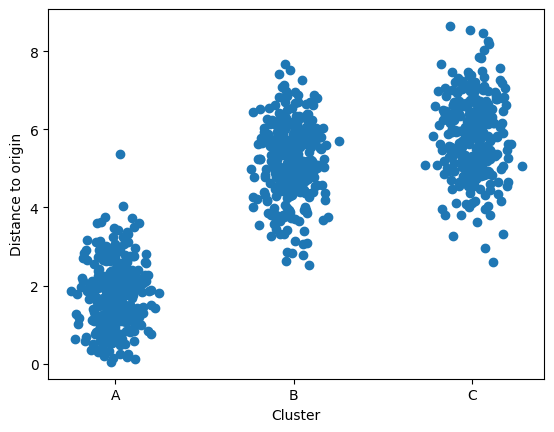

In [13]:
example = create_data(300, use_extra_feature=True)

data = example["data"]
labels = example["labels"]

plt.plot(labels + torch.randn(900)/10, data[:, -1], "o")
plt.xticks([0, 1, 2], ["A", "B", "C"])
plt.xlabel("Cluster")
plt.ylabel("Distance to origin")

In [22]:
lr = 0.001
epochs = 200
use_extra_features = [False, True]
loss_fn = nn.CrossEntropyLoss()

train_accs = np.zeros((2, epochs))
test_accs = np.zeros((2, epochs))

for i, use_extra_feature in enumerate(use_extra_features):

    data_generated = create_data(300, use_extra_feature=use_extra_feature)
    test_dl = data_generated["test_dl"]
    train_dl = data_generated["train_dl"]

    model = Cluster_FNN(use_extra_feature=use_extra_feature)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)
    train_accs[i] = train_acc
    test_accs[i] = test_acc

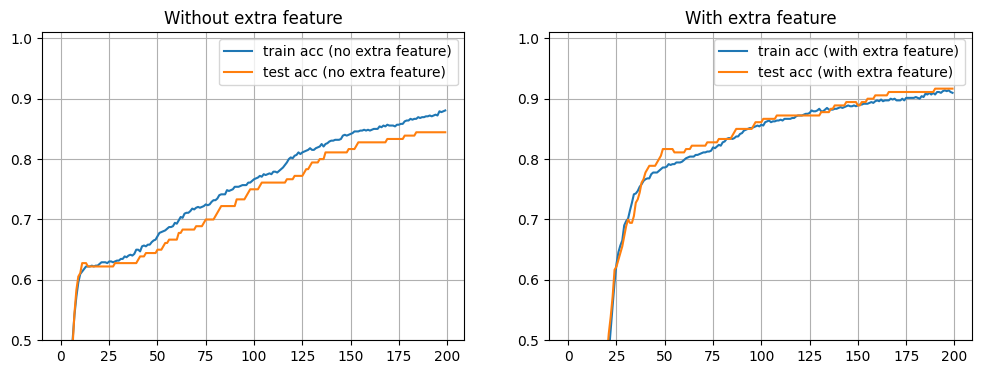

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_accs[0], label="train acc (no extra feature)")
ax[0].plot(test_accs[0], label="test acc (no extra feature)")
ax[0].set_title("Without extra feature")
ax[0].legend()
ax[0].set_ylim(0.5, 1.01)
ax[0].grid()
ax[1].plot(train_accs[1], label="train acc (with extra feature)")
ax[1].plot(test_accs[1], label="test acc (with extra feature)")
ax[1].set_title("With extra feature")
ax[1].legend()
ax[1].set_ylim(0.5, 1.01)
ax[1].grid()

# normally there is no advantage of adding a new feature that is a linear combination of the existing features,
# but in this case the distance to the origin is a non-linear combination of the existing features, so it can 
# help the model to separate the clusters, but still not guaranteed to improve performance.

# however to determine better this, we should let the model to converge and then run a statistical test to determine 
# if the difference in accuracy is significant or not.

In [ ]:
# Run a t-test to see if the difference in test accuracies is statistically significant
# the t-test will compare the means of the two groups of test accuracies (with and without extra feature) 
# and tell us if the difference is statistically significant or not.

# if the p-value is less than 0.05, we can reject the null hypothesis that the means of the two groups are equal,
# and conclude that there is a statistically significant difference between the two groups.

# if the p-value is greater than 0.05, we fail to reject the null hypothesis, and we cannot conclude that there is 
# a statistically significant difference between the two groups.

# the value of the t-statistic will tell us how many standard deviations the means of the two groups are apart.

final_acc_extend = np.zeros(10)
final_acc_normal = np.zeros(10)

def run_model(use_extra_feature):
    lr = 0.005
    epochs = 250

    data_generated = create_data(300, use_extra_feature=use_extra_feature)
    test_dl = data_generated["test_dl"]
    train_dl = data_generated["train_dl"]

    model = Cluster_FNN(use_extra_feature=use_extra_feature)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    _, test_acc, _ = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)

    return np.mean(test_acc[-5:]) # return the average of the last 5 test accuracies

for i in range(10):
    final_acc_extend[i] = run_model(use_extra_feature=True)
    final_acc_normal[i] = run_model(use_extra_feature=False)

t, p = stats.ttest_ind(final_acc_extend, final_acc_normal)

print(f"t-statistic: {t:.4f}, p-value: {p:.4f}")

In [ ]:
# how to save the model in pytorch
torch.save(model.state_dict(), "cluster_fnn_example.pth")

# to load it again we need to create a new instance of the model and then load the state dict
model_loaded = Cluster_FNN(use_extra_feature=True) # create a new instance of the model
model_loaded.load_state_dict(torch.load("cluster_fnn_example.pth")) # load the saved